# 02 · Train / Test — split out-of-period + GroupKFold

**El split va PRIMERO** — antes del preprocessing y del modelado. Es la regla de
oro para evitar *leakage*: una vez definidos train/test, cualquier estadístico
data-derived (imputación con medianas, scaling, selección por importancia,
tuning) se ajusta **solo en train**.

Definimos los **dos protocolos de validación** de los papers
(Gattermann-Itschert & Thonemann). Operan sobre el dataset **crudo**
(`churn_dataset.csv`): solo necesitan `mes_rank` e `id_vendedor`, no las features.

## Por qué dos protocolos

| Protocolo | Qué simula | Para qué |
|---|---|---|
| **Out-of-period (OOT)** | Producción: entrenar con el pasado, predecir el futuro | Métrica realista de despliegue |
| **GroupKFold por vendedora** | CV honesta sin leakage de identidad | Estimar generalización; misma vendedora nunca en train+test |

### OOT — el detalle del *gap*

Cada observación en `t` tiene su etiqueta mirando a `[t+1, t+6]` (v=6). Si train
llega hasta el mes `T` y test empieza en `T+1`, sus ventanas de etiqueta se
**solapan**. Para evitarlo, los papers desplazan el test **v meses**: dejamos un
**gap de 6 meses** entre el último mes de train y el primero de test.

```
train  [........... features|labels]
                              <-- gap v=6 -->
test                                         [features|labels]
```

### GroupKFold — evitar leakage de identidad

Una vendedora aparece en muchos meses (multi-slicing). `GroupKFold` con
`groups=id_vendedor` garantiza que todas sus filas caigan en el mismo fold.


## 0 · Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

# El split opera sobre el dataset CRUDO (antes del preprocessing): solo usa
# mes_rank / id_vendedor / churn, que no cambian con el preprocessing.
df = pd.read_csv(base / "data" / "processed" / "churn_dataset.csv", parse_dates=["mes_obs"])
print(f"dataset (crudo): {df.shape[0]:,} x {df.shape[1]}")
print(f"meses de observación: {df['mes_obs'].min().date()} -> {df['mes_obs'].max().date()}")

dataset (crudo): 30,356 x 29
meses de observación: 2016-12-01 -> 2025-11-01


## 1 · Funciones de split

Las definimos acá mismo (auto-contenido). `05_modelling` redefine estas mismas
funciones para reusar el split.


In [2]:
def oot_split(df, v=6, test_months=6, rank_col="mes_rank"):
    """(train_mask, test_mask) para un split out-of-period.

    test  = últimos `test_months` meses de observación.
    gap   = `v` meses descartados entre train y test (sin solape de etiquetas).
    train = todo lo anterior al gap.
    """
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


def group_cv(n_splits=5):
    """GroupKFold; usar con groups=df['id_vendedor'] para evitar leakage de identidad."""
    return GroupKFold(n_splits=n_splits)

## 2 · Split out-of-period

In [3]:
TEST_MONTHS = 4
train_mask, test_mask = oot_split(df, v=6, test_months=TEST_MONTHS)
gap_mask = ~train_mask & ~test_mask

print(f"v (gap) = 6 meses | bloque test = {TEST_MONTHS} meses\n")
for nm, m in [("TRAIN", train_mask), ("GAP (descartado)", gap_mask), ("TEST", test_mask)]:
    sub = df[m]
    rng = f"{sub['mes_obs'].min().date()} -> {sub['mes_obs'].max().date()}" if len(sub) else "-"
    cr = f"{sub['churn'].mean():.3f}" if len(sub) else "-"
    print(f"{nm:18s}: {m.sum():>6,} filas | {sub['id_vendedor'].nunique():>5} vend | churn {cr} | {rng}")

ov = len(set(df.loc[train_mask,'id_vendedor']) & set(df.loc[test_mask,'id_vendedor']))
print(f"\nVendedoras en test que también están en train: {ov}/{df.loc[test_mask,'id_vendedor'].nunique()}")
print("(esperado y REALISTA en OOT: se reentrena con su historia y se predice su futuro; no es leakage)")

v (gap) = 6 meses | bloque test = 4 meses

TRAIN             : 28,311 filas |  6128 vend | churn 0.310 | 2016-12-01 -> 2025-01-01
GAP (descartado)  :  1,242 filas |   688 vend | churn 0.312 | 2025-02-01 -> 2025-07-01
TEST              :    803 filas |   492 vend | churn 0.262 | 2025-08-01 -> 2025-11-01

Vendedoras en test que también están en train: 406/492
(esperado y REALISTA en OOT: se reentrena con su historia y se predice su futuro; no es leakage)


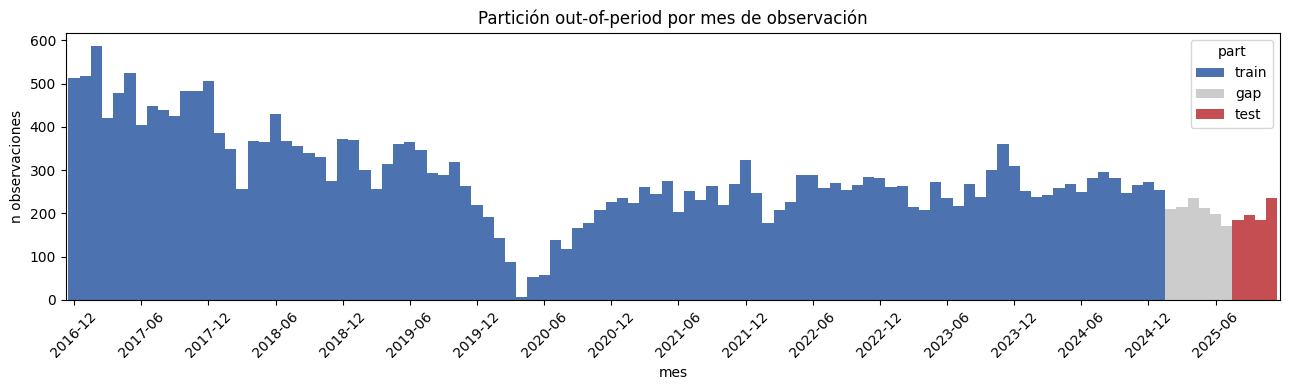

In [4]:
serie = df.assign(part=np.where(train_mask,"train",np.where(test_mask,"test","gap")))
piv = (serie.groupby([serie["mes_obs"].dt.to_period("M").astype("datetime64[ns]"),"part"])
            .size().unstack(fill_value=0))
ax = piv.reindex(columns=["train","gap","test"]).plot.bar(
    stacked=True, color={"train":"#4c72b0","gap":"#cccccc","test":"#c44e52"}, width=1.0, figsize=(13,4))
ax.set_title("Partición out-of-period por mes de observación")
ax.set_xlabel("mes"); ax.set_ylabel("n observaciones")
ax.set_xticks(range(0, len(piv), 6)); ax.set_xticklabels([str(piv.index[i].date())[:7] for i in range(0,len(piv),6)], rotation=45)
plt.tight_layout(); plt.show()

## 3 · GroupKFold por vendedora

In [5]:
gkf = group_cv(n_splits=5)
groups = df["id_vendedor"].values
y = df["churn"].values

print("Folds GroupKFold(5) — verificación de no-solape de vendedoras:")
for i,(tr,te) in enumerate(gkf.split(df, y, groups)):
    overlap = set(groups[tr]) & set(groups[te])
    print(f"  fold {i}: train {len(tr):>6,} | test {len(te):>5,} | "
          f"churn test {y[te].mean():.3f} | vendedoras solapadas: {len(overlap)}")
print("\n✓ 0 vendedoras solapadas en todos los folds = sin leakage de identidad")

Folds GroupKFold(5) — verificación de no-solape de vendedoras:
  fold 0: train 24,284 | test 6,072 | churn test 0.320 | vendedoras solapadas: 0
  fold 1: train 24,285 | test 6,071 | churn test 0.311 | vendedoras solapadas: 0
  fold 2: train 24,285 | test 6,071 | churn test 0.306 | vendedoras solapadas: 0
  fold 3: train 24,285 | test 6,071 | churn test 0.306 | vendedoras solapadas: 0
  fold 4: train 24,285 | test 6,071 | churn test 0.303 | vendedoras solapadas: 0

✓ 0 vendedoras solapadas en todos los folds = sin leakage de identidad


## 4 · Resumen

- **OOT**: train (pasado) / gap 6m / test (últimos **4 meses**). El overlap de
  vendedoras train↔test es realista (producción), no leakage.
- **GroupKFold**: 0 vendedoras solapadas entre folds → CV honesta.
- Las funciones `oot_split` / `group_cv` se redefinen en `05_modelling` para
  reusar el split (auto-contenido, sin módulos externos).

Reportar **siempre las dos** métricas: GroupKFold (generalización honesta) y OOT
(escenario de producción).

**Próximo paso:** `03_preprocessing`.